# Exploratory Data Analysis Dashboard with Seaborn

## Introduction
This notebook uses Seaborn to create exploratory visualizations of the `diamonds` dataset, showing:
* statistical relationships between numeric variables
* variable distributions
* comparisons across categories

### Load the Dataset

In [23]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
diamantes = sns.load_dataset('diamonds')
diamantes.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### General Dataset Information

In [24]:
diamantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [25]:
diamantes.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Null Values
No null or missing values are present according to `.info()`.

### Dataset Columns
1. **carat** = weight of the diamond in carats. Equivalent to 0.2 grams.
2. **cut** = quality of the diamond's cut and shape: 'Ideal', 'Premium', 'Very Good', 'Good', 'Fair'.
3. **color** = diamond color grade, from 'D' (colorless, most valuable) to 'Z' (yellowish/brownish tint).
4. **clarity** = how many internal imperfections it has: 'IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'.
5. **depth** = depth percentage that optimizes light reflection.
6. **table** = width of the flat top facet, as a % of the gem's total width.
7. **price** = price in US dollars.
8. **x, y, z** = length, width, and depth in mm.

### Data Cleaning: Physically Impossible Values
Although `.info()` shows no nulls, a diamond cannot have 0 mm of length, width, or depth. These zeros are loading/measurement errors, not valid data. We identify and remove them before continuing, along with an extreme outlier in `y`/`z` that distorts the scale of several plots.

In [26]:
ceros = diamantes[(diamantes['x'] == 0) | (diamantes['y'] == 0) | (diamantes['z'] == 0)]
print(f"Rows with x, y or z en 0: {len(ceros)}")

outlier_extremo = diamantes[(diamantes['y'] > 20) | (diamantes['z'] > 20)]
print(f"Rows with y or z > 20mm (outliers): {len(outlier_extremo)}")

diamantes_clean = diamantes[
    (diamantes['x'] > 0) & (diamantes['y'] > 0) & (diamantes['z'] > 0) &
    (diamantes['y'] < 20) & (diamantes['z'] < 20)
].copy()

print(f"\nOriginal number of rows: {len(diamantes)} | Clean rows: {len(diamantes_clean)} | Removed: {len(diamantes) - len(diamantes_clean)}")

Rows with x, y or z en 0: 20
Rows with y or z > 20mm (outliers): 3

Original number of rows: 53940 | Clean rows: 53917 | Removed: 23


### Distribution by Cut, Color, and Clarity

In [27]:
for columna in ['cut', 'color', 'clarity']:
    print(f"--- {columna} ---")
    print(diamantes_clean[columna].value_counts())
    print()

--- cut ---
cut
Ideal        21547
Premium      13779
Very Good    12080
Good          4902
Fair          1609
Name: count, dtype: int64

--- color ---
color
G    11284
E     9795
F     9538
H     8297
D     6774
I     5421
J     2808
Name: count, dtype: int64

--- clarity ---
clarity
SI1     13063
VS2     12254
SI2      9184
VS1      8168
VVS2     5066
VVS1     3654
IF       1790
I1        738
Name: count, dtype: int64



**Quick read:**
- **Cut**: `Ideal` predominates (21,551), followed by `Premium` and `Very Good`. `Fair` is the least common (1,610).
- **Color**: `G` (near-colorless) predominates, not the extremes D or J.
- **Clarity**: `SI1` predominates, a medium clarity grade, neither the best (`IF`) nor the worst (`I1`).

Overall, the market represented in this dataset is concentrated in medium-high quality, not extreme pieces of any attribute.

### Correlation Matrix
Before interpreting the scatter plots, we compute the Pearson correlation between the numeric variables.

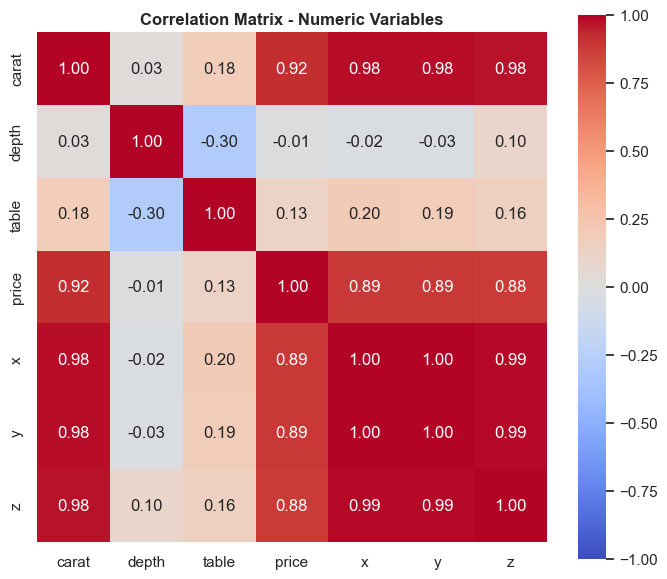

In [28]:
correlaciones = diamantes_clean.corr(numeric_only=True)

plt.figure(figsize=(7, 6))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix - Numeric Variables', weight='bold')
plt.tight_layout()
plt.show()

**Reading:**
- `carat`–`price`: **0.92**, a very strong positive correlation. This is the numerical basis for weight being the main price driver visible in the plots.
- `depth`–`price`: **-0.01** and `table`–`price`: **0.13**, practically no linear relationship. This numerically confirms what the depth/table relplot suggests: these variables do not explain price.
- `carat`, `x`, `y`, `z` are correlated between 0.95–0.98 with each other; in practice they are four ways of measuring the same thing (physical size). That's why the full pairplot was redundant across those crossings.

Since the carat-price pattern looks curved (not a straight line) in the scatter plot, we also test the correlation on a logarithmic scale, to check whether the relationship is exponential in shape:

In [29]:
corr_log = np.corrcoef(np.log(diamantes_clean['carat']), np.log(diamantes_clean['price']))[0, 1]
print(f"Correlación carat-price (lineal):        {correlaciones.loc['carat','price']:.3f}")
print(f"Correlación log(carat)-log(price):        {corr_log:.3f}")

Correlación carat-price (lineal):        0.922
Correlación log(carat)-log(price):        0.966


Since the log-log correlation is higher than the linear one, there is quantitative (not just visual) evidence that the relationship between `carat` and `price` follows an exponential shape better than a straight line.

### Price-Carat Relationship by Cut and Color

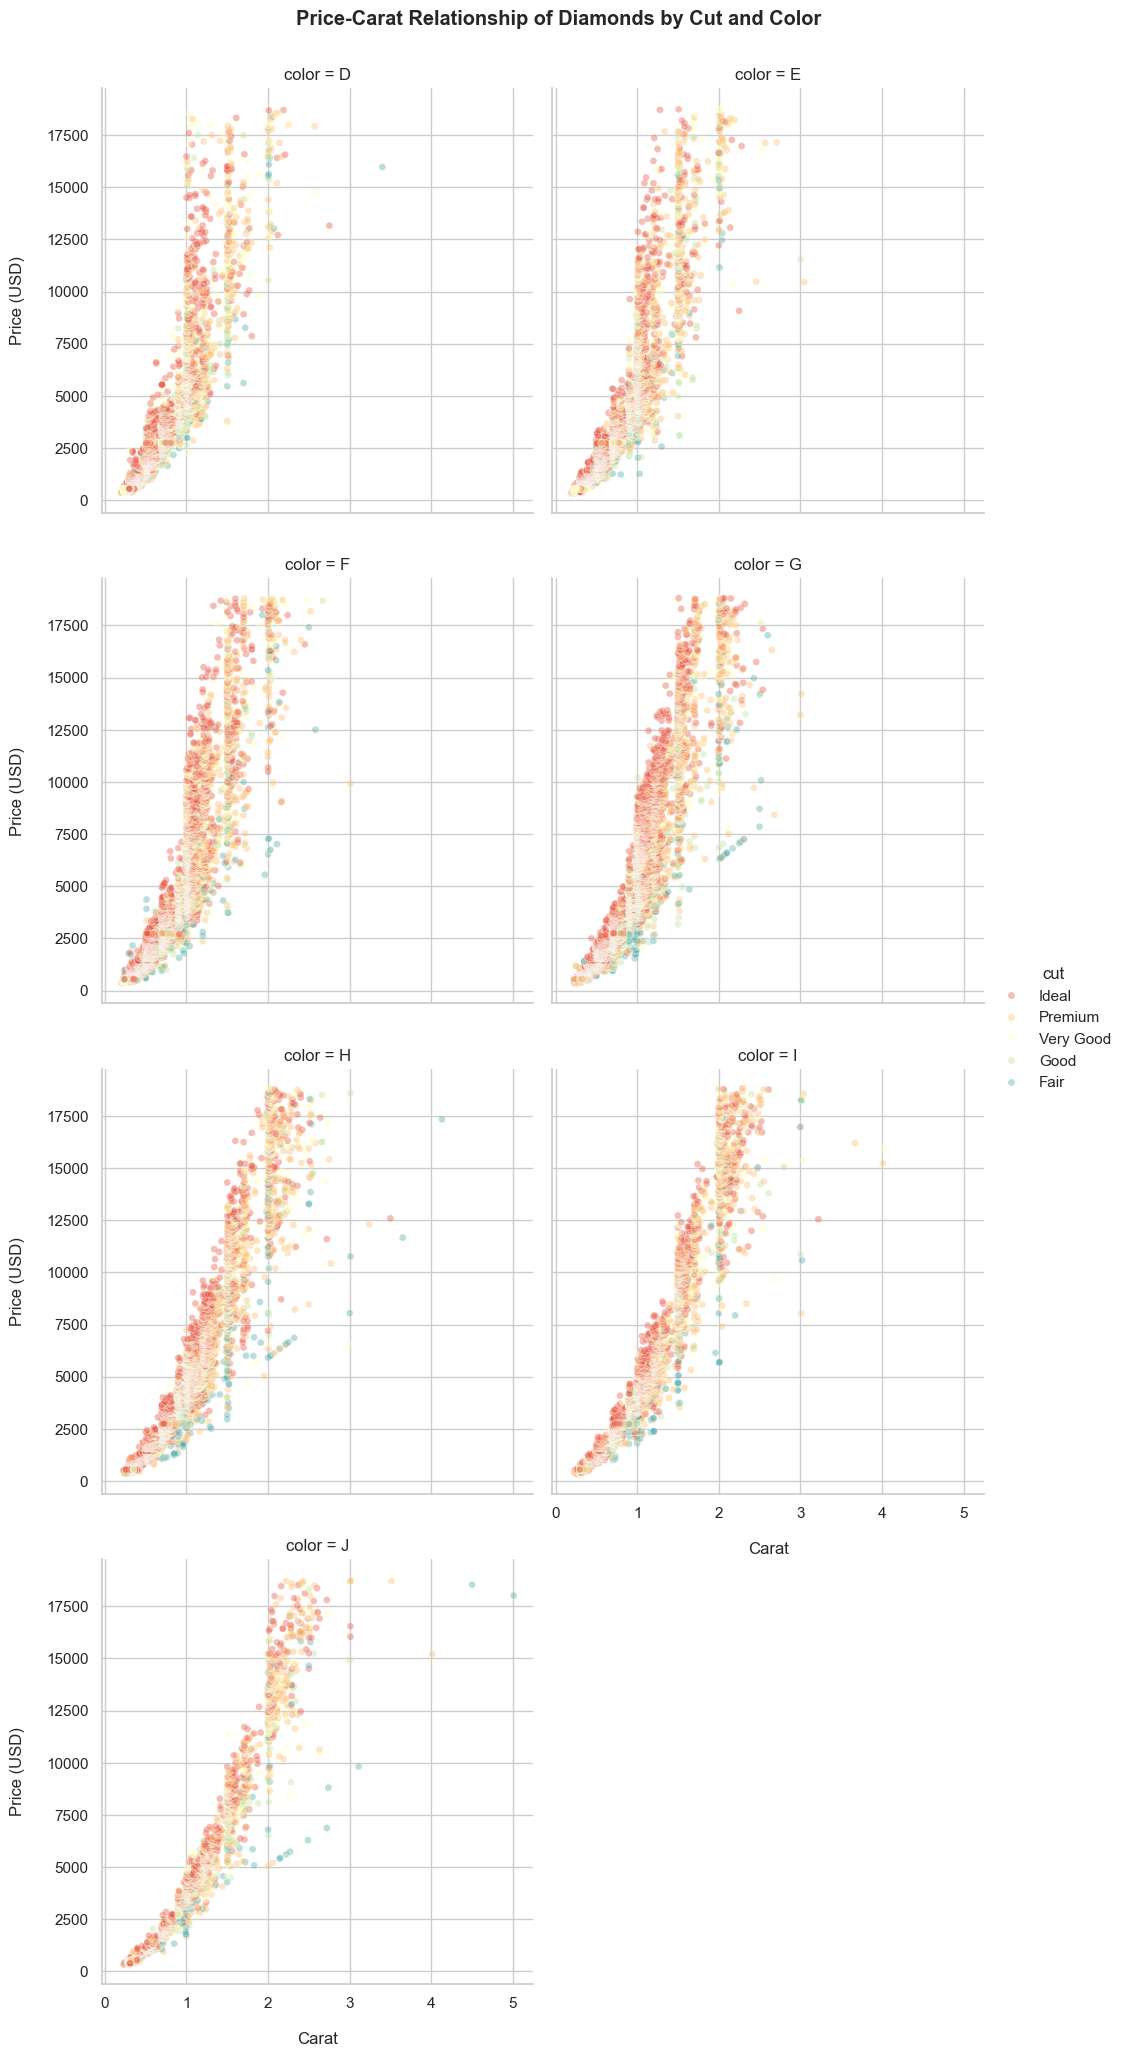

In [30]:
g = sns.relplot(
    data=diamantes_clean, x='carat', y='price', hue='cut',
    palette='Spectral', col='color', col_wrap=2, alpha=0.4, s=25
)
g.set_axis_labels('Carat', 'Price (USD)', labelpad=15)
g.fig.suptitle('Price-Carat Relationship of Diamonds by Cut and Color', weight='bold', y=1.02)
plt.show()

### Relationship Between Price and Light Reflection Percentage (Depth)

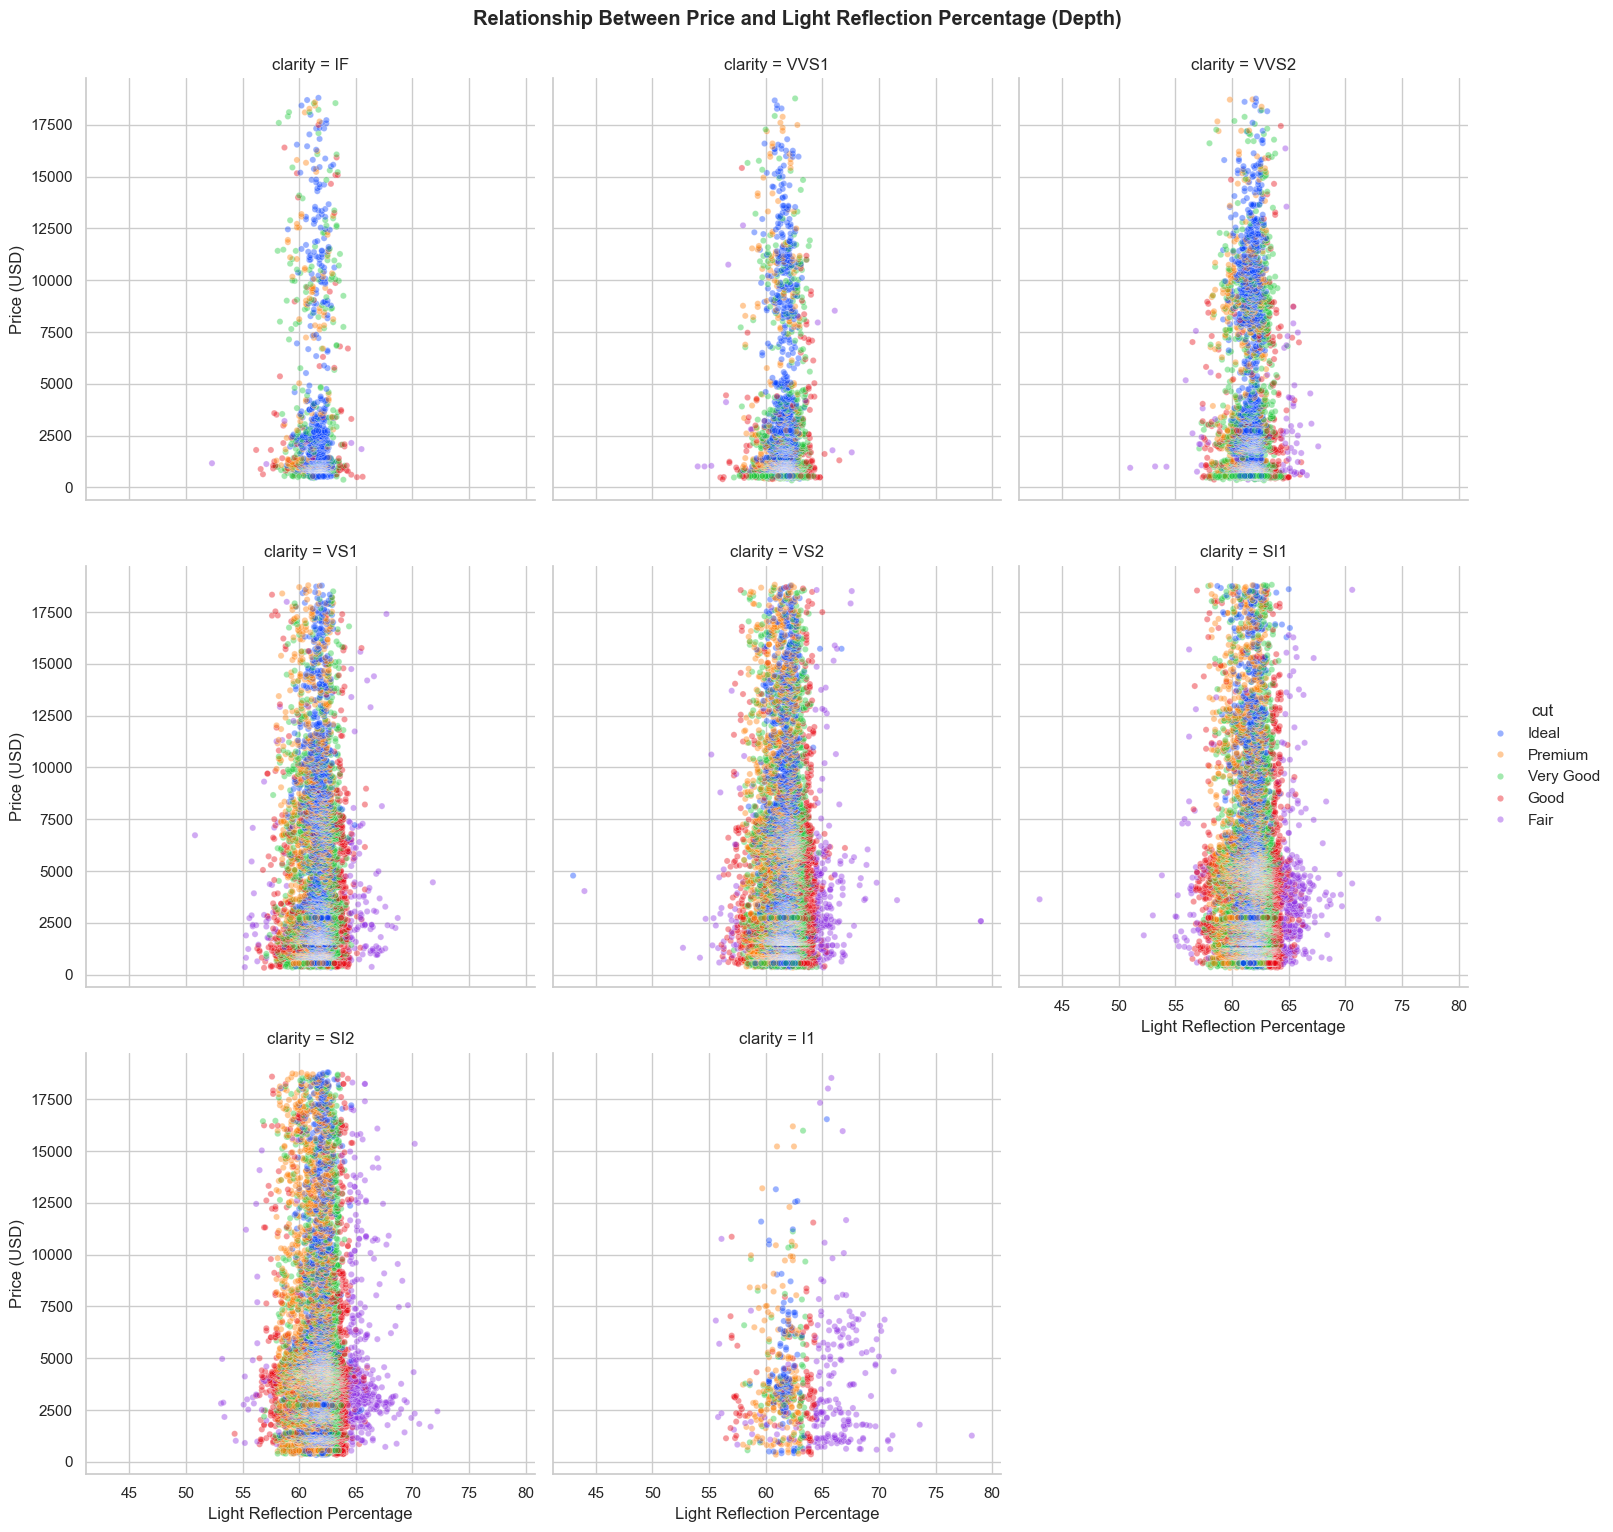

In [31]:
g = sns.relplot(
    data=diamantes_clean, x='depth', y='price', hue='cut',
    col='clarity', col_wrap=3, palette='bright', alpha=0.4, s=20
)
g.set_axis_labels('Light Reflection Percentage', 'Price (USD)')
g.fig.suptitle('Relationship Between Price and Light Reflection Percentage (Depth)', y=1.02, weight='bold')
plt.show()

### Distribution of Diamond Weight

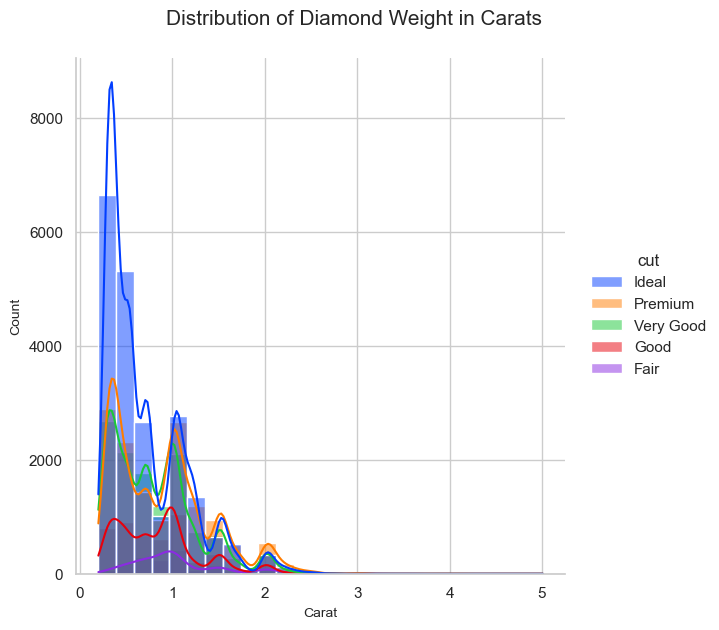

In [32]:
g = sns.displot(
    data=diamantes_clean, x='carat', bins=25, kde=True, hue='cut',
    palette='bright', height=6, alpha=0.5
)
g.set_axis_labels('Carat', 'Count', fontsize=10, labelpad=5)
g.fig.suptitle('Distribution of Diamond Weight in Carats', fontsize=15, y=1.05)
plt.show()

### Price by Clarity, Color, and Cut

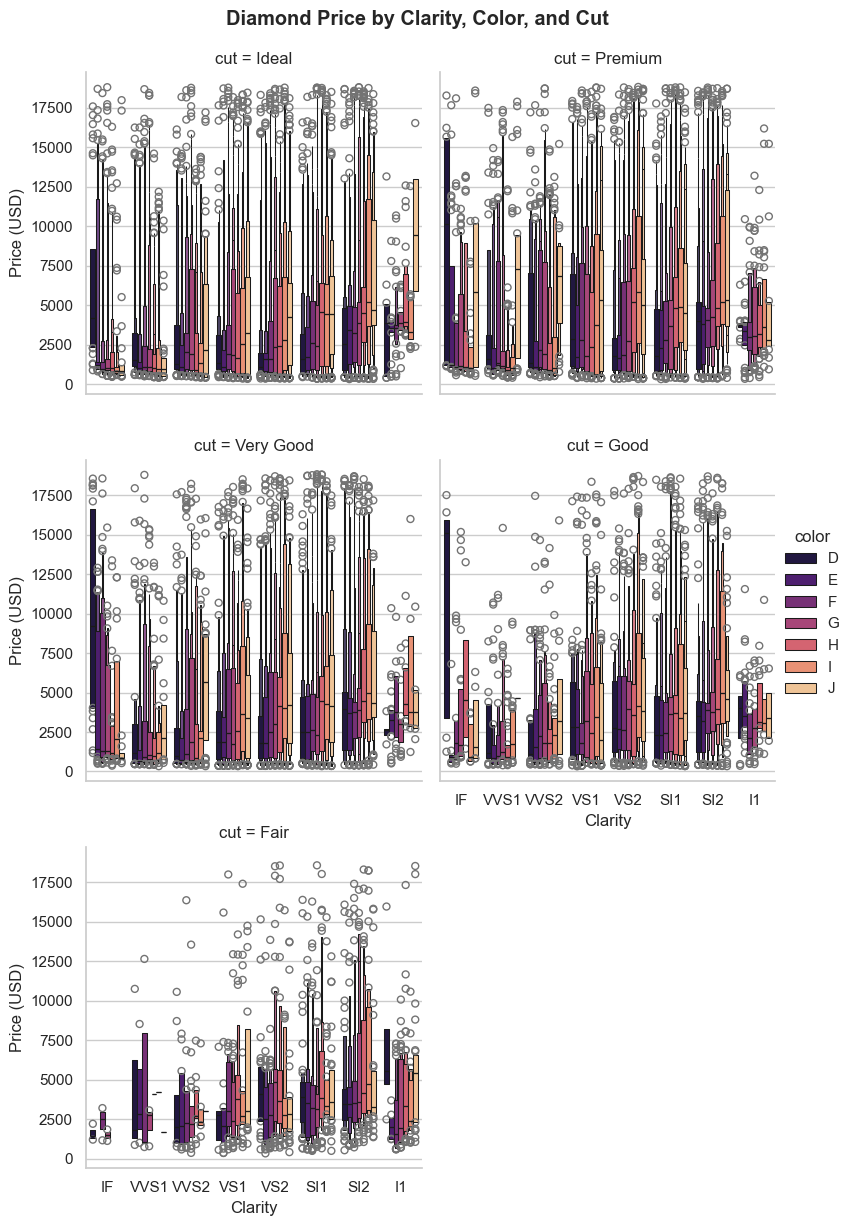

In [33]:
g = sns.catplot(
    data=diamantes_clean, x='clarity', y='price', kind = 'boxen',
    hue='color', col='cut', col_wrap=2, palette='magma', height=4
)
g.set_axis_labels('Clarity', 'Price (USD)')
g.fig.suptitle('Diamond Price by Clarity, Color, and Cut', y=1.02, weight='bold')
plt.show()

### Relationship Between Top Face Width (Table) and Price

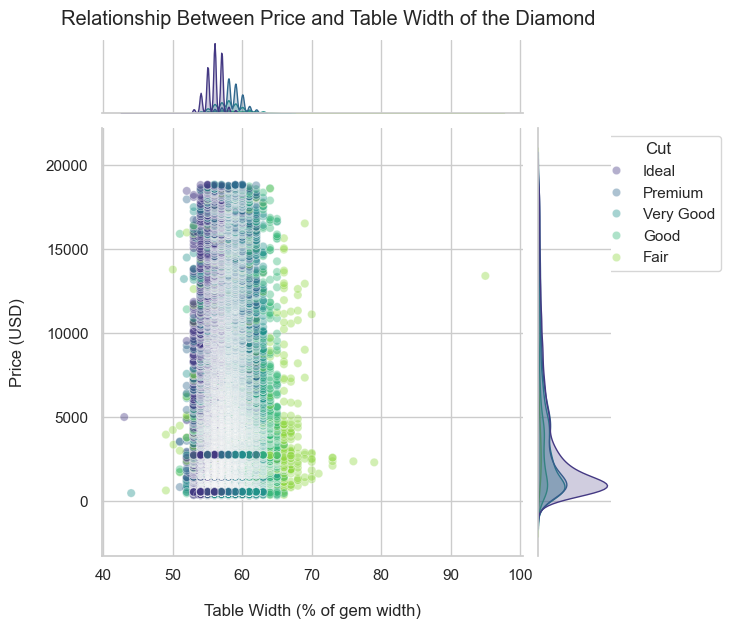

In [34]:
g = sns.jointplot(
    data=diamantes_clean, x='table', y='price', hue='cut',
    height=6, palette='viridis', alpha=0.4
)
g.set_axis_labels('Table Width (% of gem width)', 'Price (USD)', labelpad=15)
g.fig.suptitle('Relationship Between Price and Table Width of the Diamond', y=1.02)
sns.move_legend(g.ax_joint, 'upper left', bbox_to_anchor=(1.15, 1), title='Cut')
plt.show()

### Pair Plot

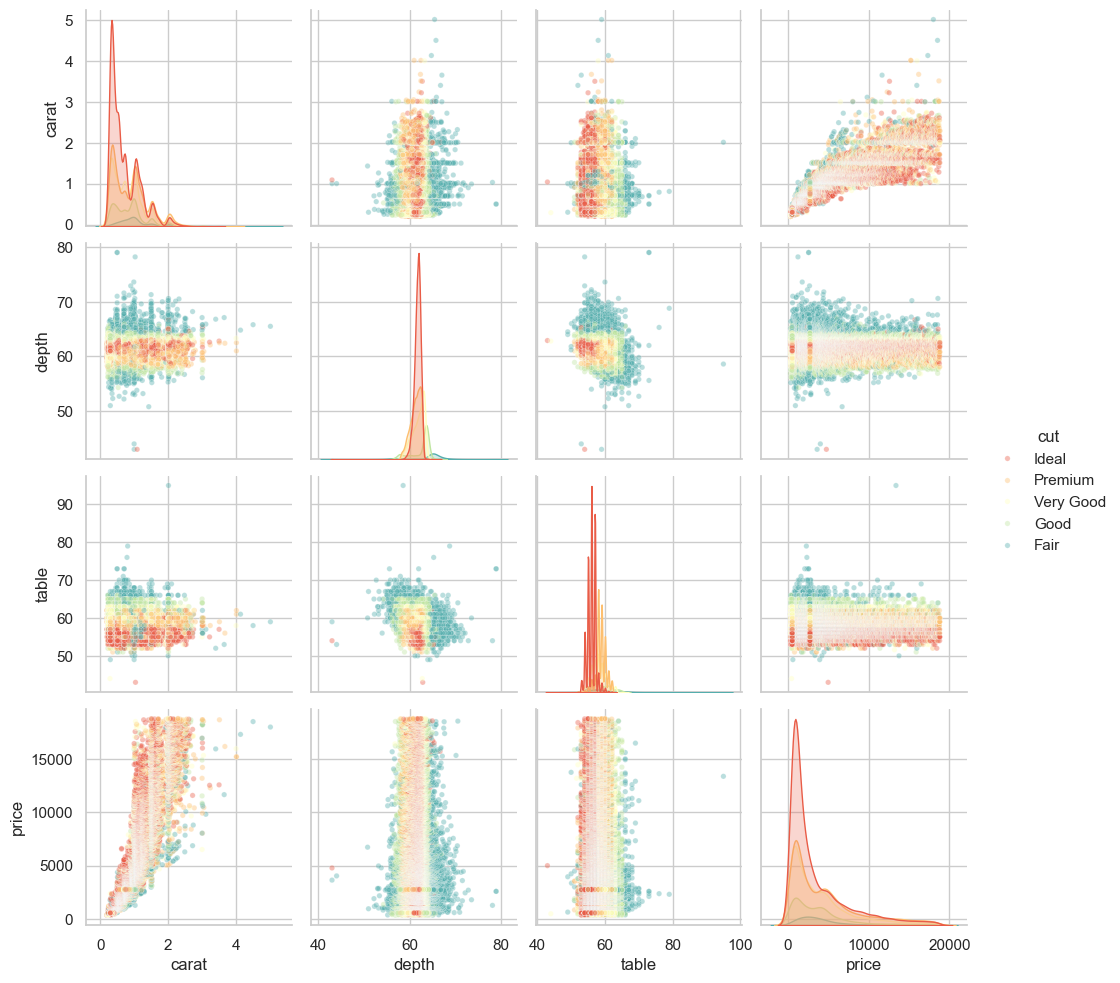

In [35]:
sns.pairplot(
    data=diamantes_clean, vars=['carat', 'depth', 'table', 'price'],
    hue='cut', palette='Spectral', plot_kws={'alpha': 0.4, 's': 15}
)
plt.show()

## Data Interpretation

**Chart 1. Price-Carat Relationship by Cut and Color**
Price increases with weight, with a linear correlation of 0.92 and an even higher log-log correlation, meaning the relationship is not a straight line but closer to a power function, quantitatively confirming what the curved shape of the scatter shows. Color slightly shifts the point at which price jumps: in color D (colorless), high prices already appear between 1-2 carats, while in J, more weight (2-3 carats) is needed to reach similar prices. The outlier cases (>$17,000 USD) correspond to high-weight pieces even with suboptimal cut/color.

**Chart 2. Relationship Between Price and Depth**
The depth-price correlation is -0.01 and table-price is 0.13, practically null. This numerically supports the visual observation: almost all diamonds, regardless of price, are concentrated in the 55%-70% depth range. Neither clarity nor cut changes this pattern. The correct interpretation is that depth/table are manufacturing constraints, not variables that explain why one diamond is worth more than another.

## Conclusions

- **Weight (carat) is the dominant variable in price**, with a correlation of 0.92 (linear) and even higher on a logarithmic scale, quantitative, not just visual, evidence of a power-law relationship between the two variables.
- **Color modulates the price "jump" point**: better-color diamonds (D) reach high prices with less weight than worse-color diamonds (J), although this effect is secondary compared to weight.
- **Depth and table show no relationship with price** (correlations close to 0). They operate as technical manufacturing standards that almost all diamonds meet, not as value-differentiating factors.
- **The market in this dataset is concentrated** in diamonds under 2 carats, medium clarity (VS1/VS2/SI1/SI2), and Ideal cut; that is, medium-high quality, not extreme pieces.
- **Important limitation**: rows with physically impossible measurements (x, y, or z = 0) and an extreme measurement outlier were detected and removed; if left unfiltered, they would have distorted the pairplot and the conclusions about relationships between size variables.

## Business Insights

*Note: the dataset only contains sale price, not costs or margins. The following are reasonable business hypotheses based on the observed price patterns, and would require additional data (acquisition cost, demand, inventory turnover) to be validated as an actual strategy.*

- **Weight as the main price lever**: since weight explains most of the price variation, and cut/depth/table have almost no influence, prioritizing physical volume over cut perfection could be a valid strategy, but this is a hypothesis to test with cost data, not a conclusion of the EDA itself.
- **Segmentation by color**: in high-end pieces, color appears to allow reaching premium prices with less weight, which could inform assortment decisions, again, subject to validation with real margins.
- **Depth/table as a standard, not a differentiator**: since they don't influence price, they don't provide a sales argument on their own; the commercial focus should be on weight and color.
- **Inventory concentration**: most of the analyzed market falls in the <2 carat, medium clarity range; this suggests that segment has the highest turnover, although "turnover" and "demand" are not directly measured in this dataset and this reading is based on supply volume, not sales data.